# Mini-Project 1: UBOS District Population Forecaster

## Purpose
This project estimates district populations for 2025–2029 to support
primary-school classroom planning. It compares linear trend, compound
annual growth (CAGR), and Fibonacci-ratio forecasting models.

## Data and assumptions
The dataset covers 2015–2024 for Kampala, Wakiso, Gulu, Mbarara and Jinja.
All population values are in thousands. The figures are illustrative,
not verified UBOS estimates. Mbarara and Jinja are the two additional
districts included in this analysis.

Classroom estimates assume that 18% of the population is of primary-school
age and that each classroom accommodates 53 pupils.

## Approach
Models are trained on 2015–2021 and evaluated against 2022–2024 using
MAE, RMSE and MAPE. The selected models are then fitted to the full
historical dataset to forecast 2025–2029.

## 1. Import libraries and forecasting classes
The following cell loads the analysis libraries and imports the reusable
classes from `src/population_forecaster.py`.

In [74]:
import sys
from pathlib import Path

# Locate the project folder from either the root or notebooks folder.
project_folder = Path.cwd()
if not (project_folder / "src").is_dir():
    project_folder = project_folder.parent

# Allow Python to find our reusable code in the src folder.
sys.path.insert(0, str(project_folder))

# Load tools for arrays, tables, statistics and charts.
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt

# Import the district class, forecasting models and bootstrap function.
from src.population_forecaster import (
    DistrictPopulation,
    LinearTrendForecaster,
    CAGRForecaster,
    FibonacciForecaster,
    bootstrap_prediction_interval
)

print("Project 1 setup successful!")

Project 1 setup successful!


## 2. Prepare the district population data

Each district has ten annual population values covering 2015–2024.
Values are measured in thousands, so 1,200 represents 1,200,000 people.

Kampala, Wakiso and Gulu use the illustrative figures supplied in the
assignment. Mbarara and Jinja use additional synthetic figures for this
exercise. These figures should not be treated as official district totals.

The arrays follow the same year order, allowing population values to be
matched correctly with their corresponding years.

In [75]:
# Create the years 2015–2024; the stop value 2025 is excluded.
years = np.arange(2015, 2025)

# Store the three supplied district series in thousands of people.
kampala = np.array([
    1200, 1250, 1300, 1350, 1420,
    1500, 1580, 1650, 1720, 1800
])

wakiso = np.array([
    950, 1000, 1070, 1150, 1220,
    1300, 1390, 1480, 1570, 1670
])

gulu = np.array([
    320, 330, 345, 360, 375,
    390, 410, 430, 455, 480
])

# Add illustrative population series for Mbarara and Jinja.
mbarara = np.array([
    450, 470, 495, 520, 550,
    580, 610, 640, 675, 710
])

jinja = np.array([
    380, 400, 425, 450, 475,
    505, 535, 565, 600, 635
])

print(years)
print("Data loaded successfully!")

[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
Data loaded successfully!


## 3. Create district population objects

Each DistrictPopulation object stores a district's name, years and
population values. The class checks that the year and population arrays
have equal lengths, that the data is not empty, and that populations
are not negative.

A dictionary connects each district name to its object, allowing the
same calculations to be applied to all five districts.

The class also implements __repr__ to display a short description and
__len__ to return the number of observations.

In [76]:
# Create one population object per district and store them by name.
districts = {
    "Kampala": DistrictPopulation("Kampala", years, kampala),
    "Wakiso": DistrictPopulation("Wakiso", years, wakiso),
    "Gulu": DistrictPopulation("Gulu", years, gulu),
    "Mbarara": DistrictPopulation("Mbarara", years, mbarara),
    "Jinja": DistrictPopulation("Jinja", years, jinja)
}

print(districts)

{'Kampala': DistrictPopulation(district='Kampala', observations=10), 'Wakiso': DistrictPopulation(district='Wakiso', observations=10), 'Gulu': DistrictPopulation(district='Gulu', observations=10), 'Mbarara': DistrictPopulation(district='Mbarara', observations=10), 'Jinja': DistrictPopulation(district='Jinja', observations=10)}


In [77]:
# Display Kampala's object description using __repr__.
print(districts["Kampala"])

# Use __len__ to check how many annual observations it contains.
print("Number of observations:", len(districts["Kampala"]))

DistrictPopulation(district='Kampala', observations=10)
Number of observations: 10


## 4. Summarise district populations

The mean and median describe the population level across 2015–2024.
Variance and standard deviation describe how widely the annual values
differ. This variation includes the effect of population growth over time;
it does not directly measure forecast uncertainty.

Mean, median and standard deviation are expressed in thousands of people.
Variance is expressed in squared thousands of people.

The statistics module uses sample variance and standard deviation,
dividing by n − 1. NumPy defaults to division by n. Setting ddof=1
makes NumPy use the same denominator as the sample calculations.

In [78]:
# Summarise each district using Python's statistics module.
for name, district in districts.items():
    data = district.populations

    print(f"\n{name}")
    print(f"Mean: {statistics.mean(data):.2f} thousand")
    print(f"Median: {statistics.median(data):.2f} thousand")

    # Sample variance and standard deviation use the denominator n − 1.
    print(f"Sample variance: {statistics.variance(data):.2f} (thousand people)²")
    print(f"Sample standard deviation: {statistics.stdev(data):.2f} thousand")


Kampala
Mean: 1477.00 thousand
Median: 1460.00 thousand
Sample variance: 42601.11 (thousand people)²
Sample standard deviation: 206.40 thousand

Wakiso
Mean: 1280.00 thousand
Median: 1260.00 thousand
Sample variance: 60066.67 (thousand people)²
Sample standard deviation: 245.09 thousand

Gulu
Mean: 389.50 thousand
Median: 382.50 thousand
Sample variance: 2885.83 (thousand people)²
Sample standard deviation: 53.72 thousand

Mbarara
Mean: 570.00 thousand
Median: 565.00 thousand
Sample variance: 7794.44 (thousand people)²
Sample standard deviation: 88.29 thousand

Jinja
Mean: 497.00 thousand
Median: 490.00 thousand
Sample variance: 7417.78 (thousand people)²
Sample standard deviation: 86.13 thousand


In [79]:
# Calculate the same summaries with NumPy for each district.
for name, district in districts.items():
    data = district.populations

    print(f"\n{name}")
    print(f"NumPy mean: {np.mean(data):.2f} thousand")
    print(f"NumPy median: {np.median(data):.2f} thousand")

    # Compare variance using the denominators n and n − 1.
    print(f"statistics sample variance: {statistics.variance(data):.2f}")
    print(f"NumPy population variance (ddof=0): {np.var(data):.2f}")
    print(f"NumPy sample variance (ddof=1): {np.var(data, ddof=1):.2f}")

    # Compare standard deviations using the same two conventions.
    print(f"statistics sample SD: {statistics.stdev(data):.2f}")
    print(f"NumPy population SD (ddof=0): {np.std(data):.2f}")
    print(f"NumPy sample SD (ddof=1): {np.std(data, ddof=1):.2f}")

    # Check agreement when both libraries use the sample convention.
    print(
        "Sample results match:",
        np.isclose(statistics.variance(data), np.var(data, ddof=1))
        and np.isclose(statistics.stdev(data), np.std(data, ddof=1))
    )


Kampala
NumPy mean: 1477.00 thousand
NumPy median: 1460.00 thousand
statistics sample variance: 42601.11
NumPy population variance (ddof=0): 38341.00
NumPy sample variance (ddof=1): 42601.11
statistics sample SD: 206.40
NumPy population SD (ddof=0): 195.81
NumPy sample SD (ddof=1): 206.40
Sample results match: True

Wakiso
NumPy mean: 1280.00 thousand
NumPy median: 1260.00 thousand
statistics sample variance: 60066.67
NumPy population variance (ddof=0): 54060.00
NumPy sample variance (ddof=1): 60066.67
statistics sample SD: 245.09
NumPy population SD (ddof=0): 232.51
NumPy sample SD (ddof=1): 245.09
Sample results match: True

Gulu
NumPy mean: 389.50 thousand
NumPy median: 382.50 thousand
statistics sample variance: 2885.83
NumPy population variance (ddof=0): 2597.25
NumPy sample variance (ddof=1): 2885.83
statistics sample SD: 53.72
NumPy population SD (ddof=0): 50.96
NumPy sample SD (ddof=1): 53.72
Sample results match: True

Mbarara
NumPy mean: 570.00 thousand
NumPy median: 565.00 

## 5. Compare population growth rates

Year-on-year growth measures the percentage change from one year to
the next. It is calculated as the population increase divided by the
previous year's population, multiplied by 100.

Ten annual observations produce nine growth rates, covering 2016–2024.
Percentage growth allows districts of different population sizes to
be compared on a relative basis.

In [80]:
# Calculate and label the nine annual growth rates for each district.
for name, district in districts.items():
    growth_percent = district.growth_rates() * 100

    print(f"\n{name}")

    # Each growth rate belongs to the later year in the comparison.
    for year, rate in zip(district.years[1:], growth_percent):
        print(f"{year}: {rate:.2f}%")


Kampala
2016: 4.17%
2017: 4.00%
2018: 3.85%
2019: 5.19%
2020: 5.63%
2021: 5.33%
2022: 4.43%
2023: 4.24%
2024: 4.65%

Wakiso
2016: 5.26%
2017: 7.00%
2018: 7.48%
2019: 6.09%
2020: 6.56%
2021: 6.92%
2022: 6.47%
2023: 6.08%
2024: 6.37%

Gulu
2016: 3.12%
2017: 4.55%
2018: 4.35%
2019: 4.17%
2020: 4.00%
2021: 5.13%
2022: 4.88%
2023: 5.81%
2024: 5.49%

Mbarara
2016: 4.44%
2017: 5.32%
2018: 5.05%
2019: 5.77%
2020: 5.45%
2021: 5.17%
2022: 4.92%
2023: 5.47%
2024: 5.19%

Jinja
2016: 5.26%
2017: 6.25%
2018: 5.88%
2019: 5.56%
2020: 6.32%
2021: 5.94%
2022: 5.61%
2023: 6.19%
2024: 5.83%


### Compound annual growth rate (CAGR)

CAGR is the constant annual growth rate that would connect the first
population value to the last through compounding. The period from
2015 to 2024 contains nine annual intervals.

Unlike the arithmetic average of year-on-year growth rates, CAGR
accounts for compounding. We use it to identify the district with
the fastest relative growth over the full period.

In [81]:
# Calculate each district's compound annual growth rate as a percentage.
district_cagrs = {}

for name, district in districts.items():
    district_cagrs[name] = district.cagr() * 100
    print(f"{name}: CAGR = {district_cagrs[name]:.2f}%")

# Identify the district with the highest relative growth over 2015–2024.
fastest_district = max(district_cagrs, key=lambda name: district_cagrs[name])

print(
    f"\nFastest-growing district: {fastest_district} "
    f"({district_cagrs[fastest_district]:.2f}% per year)"
)


Kampala: CAGR = 4.61%
Wakiso: CAGR = 6.47%
Gulu: CAGR = 4.61%
Mbarara: CAGR = 5.20%
Jinja: CAGR = 5.87%

Fastest-growing district: Wakiso (6.47% per year)


In [82]:
#--- Calculate the average year-on-year growth ---

for name, district in districts.items():
    average_growth = np.mean(district.growth_rates()) * 100

    print(f"{name}: Average YoY growth = {average_growth:.2f}%")


Kampala: Average YoY growth = 4.61%
Wakiso: Average YoY growth = 6.47%
Gulu: Average YoY growth = 4.61%
Mbarara: Average YoY growth = 5.20%
Jinja: Average YoY growth = 5.87%


## 6. Set up the forecasting models

The abstract Forecaster base class defines two methods: fit() learns
the model's parameters from historical data, and predict(horizon)
returns forecasts for the requested number of future years.

Three subclasses implement different assumptions:

- LinearTrendForecaster assumes a constant annual population increase.
- CAGRForecaster assumes a constant annual percentage growth rate.
- FibonacciForecaster repeatedly scales the latest population using
  successive Fibonacci ratios.

The Fibonacci model is included for comparison. Its ratios approach
1.618, implying annual growth of about 61.8%, which is an implausible
long-term assumption for these district populations. Its usefulness
must therefore be assessed against the held-out observations.

In [83]:
# Create one instance of each forecasting subclass.
linear = LinearTrendForecaster()
cagr_model = CAGRForecaster()
fib_model = FibonacciForecaster()

# These models will be fitted using the training data in later cells.
print("Forecaster classes created successfully!")

Forecaster classes created successfully!


## 7. Evaluate forecasts on unseen years

The models are trained using seven observations from 2015–2021.
The remaining three observations, from 2022–2024, are held out
to evaluate forecast accuracy.

The split follows time order because the task is to predict future
populations from earlier observations. Test values are not used
to fit the models.

We first demonstrate the evaluation for Kampala, then apply the
same procedure to all five districts.

In [84]:
# Select the historical years used to fit the models.
train_mask = years <= 2021
train_years = years[train_mask]

# Reserve the final three years for evaluating predictions.
test_mask = years >= 2022
test_years = years[test_mask]

print("Training years:", train_years)
print("Testing years:", test_years)

Training years: [2015 2016 2017 2018 2019 2020 2021]
Testing years: [2022 2023 2024]


### Fit the models using Kampala's training data

Each model uses only Kampala's 2015–2021 observations. The linear model
fits a straight line, while CAGR estimates a constant compound growth
rate from the first and last training values.

The Fibonacci model stores the last training population as its starting
point. Its growth ratios are predetermined rather than learned from
the district's historical growth.

In [85]:
# Extract Kampala's population values for 2015–2021.
kampala_train = kampala[train_mask]

# Fit each model using the same training years and population values.
linear = LinearTrendForecaster().fit(train_years, kampala_train)
cagr_model = CAGRForecaster().fit(train_years, kampala_train)
fib_model = FibonacciForecaster().fit(train_years, kampala_train)

print("Models fitted successfully!")

Models fitted successfully!


### Predict Kampala's population for 2022–2024

Each fitted model forecasts three years beyond the training period.
The table compares these predictions with the held-out population
values. All figures are in thousands of people.

In [86]:
# Predict the three held-out years using each fitted model.
linear_pred = linear.predict(len(test_years))
cagr_pred = cagr_model.predict(len(test_years))
fib_pred = fib_model.predict(len(test_years))

# Align predictions with their years and actual population values.
kampala_comparison = pd.DataFrame({
    "Year": test_years,
    "Actual": kampala[test_mask],
    "Linear": linear_pred,
    "CAGR": cagr_pred,
    "Fibonacci": fib_pred
})

# Round only the displayed table; retain full precision for calculations.
kampala_comparison.round(2)

,Year,Actual,Linear,CAGR,Fibonacci
0,2022,1650,1622.86,1654.13,3160.0
1,2023,1720,1685.71,1731.74,4740.0
2,2024,1800,1748.57,1812.99,7900.0


### Measure forecast accuracy

Three measures compare predictions with the held-out populations:

- MAE is the average absolute prediction error.
- RMSE gives greater weight to large errors.
- MAPE expresses the average absolute error as a percentage of actual
  population. It is suitable here because all actual values are positive.

MAE and RMSE are measured in thousands of people; MAPE is a percentage.
Lower values indicate better predictions. We use the lowest test MAPE
to select a model for each district.

In [87]:
#--- Mean Absolute Error (MAE), Root Mean Square Error (RMSE), and Mean Absolute Percentage Error () for Kampala  ---
# Let me use Kampala's held-out population values as the reference.

actual = kampala[test_mask]

# Calculate the same error measures for each model.
for model_name, predictions in {
    "Linear": linear_pred,
    "CAGR": cagr_pred,
    "Fibonacci": fib_pred
}.items():
    errors = actual - predictions

    # Measure absolute error, squared error and percentage error.
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    mape = np.mean(np.abs(errors / actual)) * 100

    print(f"\n{model_name}")
    print(f"MAE: {mae:.2f} thousand")
    print(f"RMSE: {rmse:.2f} thousand")
    print(f"MAPE: {mape:.2f}%")


Linear
MAE: 37.62 thousand
RMSE: 38.97 thousand
MAPE: 2.17%

CAGR
MAE: 9.62 thousand
RMSE: 10.39 thousand
MAPE: 0.55%

Fibonacci
MAE: 3543.33 thousand
RMSE: 4025.36 thousand
MAPE: 202.00%


### Compare models across all five districts

Each model is fitted to 2015–2021 and evaluated on 2022–2024 for
every district. Results are collected directly from the calculations,
with full precision retained for model selection.

In [88]:
# Map model names to their classes for consistent evaluation.
model_classes = {
    "Linear": LinearTrendForecaster,
    "CAGR": CAGRForecaster,
    "Fibonacci": FibonacciForecaster
}

results = []

# Evaluate all three models separately for each district.
for name, district in districts.items():
    train_data = district.populations[train_mask]
    actual = district.populations[test_mask]

    for model_name, model_class in model_classes.items():
        model = model_class().fit(train_years, train_data)
        predictions = model.predict(len(test_years))
        errors = actual - predictions

        # Store calculated errors rather than manually entering results.
        results.append([
            name,
            model_name,
            np.mean(np.abs(errors)),
            np.sqrt(np.mean(errors ** 2)),
            np.mean(np.abs(errors / actual)) * 100
        ])

# Keep full precision in the results used for model selection.
results_df = pd.DataFrame(
    results,
    columns=["District", "Model", "MAE", "RMSE", "MAPE (%)"]
)

### Compare models across all five districts

Each model is fitted to 2015–2021 and evaluated on 2022–2024 for
every district. Results are collected directly from the calculations,
with full precision retained for model selection.

In [89]:
# --- My results tables ---

from IPython.display import display

# Show one comparison table per district, rounded only for display.
for name in districts:
    print(f"\n{name} — MAE and RMSE in thousands of people")
    district_results = results_df.loc[
        results_df["District"] == name,
        ["Model", "MAE", "RMSE", "MAPE (%)"]
    ]
    display(district_results.round(2))


Kampala — MAE and RMSE in thousands of people


,Model,MAE,RMSE,MAPE (%)
0,Linear,37.62,38.97,2.17
1,CAGR,9.62,10.39,0.55
2,Fibonacci,3543.33,4025.36,202.00



Wakiso — MAE and RMSE in thousands of people


,Model,MAE,RMSE,MAPE (%)
3,Linear,49.4,52.37,3.09
4,CAGR,6.8,8.05,0.42
5,Fibonacci,3060.0,3479.87,189.87



Gulu — MAE and RMSE in thousands of people


,Model,MAE,RMSE,MAPE (%)
6,Linear,18.57,20.29,4.01
7,CAGR,9.44,10.87,2.02
8,Fibonacci,911.67,1035.64,196.04



Mbarara — MAE and RMSE in thousands of people


,Model,MAE,RMSE,MAPE (%)
9,Linear,15.18,16.54,2.21
10,CAGR,0.68,1.01,0.10
11,Fibonacci,1358.33,1543.38,197.10



Jinja — MAE and RMSE in thousands of people


,Model,MAE,RMSE,MAPE (%)
12,Linear,17.68,19.18,2.89
13,CAGR,0.66,0.84,0.11
14,Fibonacci,1183.33,1344.95,192.71


### Select the best model for each district

The model with the lowest MAPE on the 2022–2024 test period is selected
for each district. Selection uses unrounded results to avoid hiding
small differences between models.

This identifies the best-performing model among the three evaluated
over this particular period. It does not guarantee that the model
will remain best for future years.

In [90]:
# Store the model with the lowest test MAPE for each district.
best_models = {}

for name in districts:
    district_results = results_df.loc[results_df["District"] == name]

    # Select the best row by position to avoid the type-checking warning.
    best_position = int(np.argmin(district_results["MAPE (%)"].to_numpy()))
    best = district_results.iloc[best_position]

    # Save each selection inside the loop.
    best_models[name] = str(best["Model"])

# Confirm that all five district selections have been stored.
print(best_models)

{'Kampala': 'CAGR', 'Wakiso': 'CAGR', 'Gulu': 'CAGR', 'Mbarara': 'CAGR', 'Jinja': 'CAGR'}


## 8. Forecast populations for 2025–2029

CAGR achieved the lowest test MAPE for all five districts. Each selected
model is now refitted using the full 2015–2024 dataset before forecasting
the next five years.

Using all available historical observations gives the final forecasts
a starting point of 2024. The earlier test errors describe models fitted
only on 2015–2021; they do not measure the accuracy of the future forecasts.

In [91]:
# Define the five future years and prepare storage for forecasts.
forecast_years = np.arange(2025, 2030)
forecasts = {}

for name, district in districts.items():
    # Retrieve the model selected by its test MAPE.
    selected_class = model_classes[best_models[name]]

    # Refit using all ten historical observations.
    model = selected_class().fit(district.years, district.populations)
    forecasts[name] = model.predict(len(forecast_years))

    # Display forecast populations in thousands of people.
    print(f"\n{name} — {best_models[name]}")
    for year, value in zip(forecast_years, forecasts[name]):
        print(f"{year}: {value:.2f} thousand")


Kampala — CAGR
2025: 1882.95 thousand
2026: 1969.72 thousand
2027: 2060.49 thousand
2028: 2155.44 thousand
2029: 2254.76 thousand

Wakiso — CAGR
2025: 1778.03 thousand
2026: 1893.04 thousand
2027: 2015.49 thousand
2028: 2145.86 thousand
2029: 2284.67 thousand

Gulu — CAGR
2025: 502.12 thousand
2026: 525.26 thousand
2027: 549.46 thousand
2028: 574.78 thousand
2029: 601.27 thousand

Mbarara — CAGR
2025: 746.90 thousand
2026: 785.72 thousand
2027: 826.56 thousand
2028: 869.52 thousand
2029: 914.71 thousand

Jinja — CAGR
2025: 672.28 thousand
2026: 711.75 thousand
2027: 753.54 thousand
2028: 797.78 thousand
2029: 844.61 thousand


## 9. Estimate additional classrooms by 2029

Population values are converted from thousands into people. We assume
18% are of primary-school age and each classroom accommodates 53 pupils.

We calculate classroom requirements for both 2024 and 2029, rounding
each total upward to whole classrooms. The increase estimates the
additional classrooms needed due to population growth.

Since actual classroom counts are unavailable, we assume the estimated
2024 requirement is already met. These estimates exclude any existing
shortage and assume all primary-school-age children need a place.

In [92]:
# Apply the assignment's school-age share and classroom capacity.
school_age_share = 0.18
pupils_per_classroom = 53

for name, district in districts.items():
    # Convert the baseline and forecast populations into people.
    population_2024 = district.populations[-1] * 1000
    population_2029 = forecasts[name][-1] * 1000

    # Round each year's classroom requirement upward.
    classrooms_2024 = int(np.ceil(
        population_2024 * school_age_share / pupils_per_classroom
    ))
    classrooms_2029 = int(np.ceil(
        population_2029 * school_age_share / pupils_per_classroom
    ))

    # Estimate extra classrooms beyond the assumed 2024 capacity.
    additional_classrooms = max(0, classrooms_2029 - classrooms_2024)

    print(f"\n{name}")
    print(f"Estimated 2024 requirement: {classrooms_2024:,}")
    print(f"Estimated 2029 requirement: {classrooms_2029:,}")
    print(f"Additional classrooms needed: {additional_classrooms:,}")


Kampala
Estimated 2024 requirement: 6,114
Estimated 2029 requirement: 7,658
Additional classrooms needed: 1,544

Wakiso
Estimated 2024 requirement: 5,672
Estimated 2029 requirement: 7,760
Additional classrooms needed: 2,088

Gulu
Estimated 2024 requirement: 1,631
Estimated 2029 requirement: 2,043
Additional classrooms needed: 412

Mbarara
Estimated 2024 requirement: 2,412
Estimated 2029 requirement: 3,107
Additional classrooms needed: 695

Jinja
Estimated 2024 requirement: 2,157
Estimated 2029 requirement: 2,869
Additional classrooms needed: 712


## 10. Compare historical and forecast variation

We compare the population variance of the historical values for
2015–2024 with that of the forecasts for 2025–2029. Both calculations
use NumPy's default denominator, n.

These variances measure the spread of population levels across years,
not forecast uncertainty. The periods differ in length: ten historical
years versus five forecast years. A lower forecast variance may partly
reflect the shorter period and does not establish greater accuracy.

Variance is expressed in squared thousands of people.

In [93]:
# Compare the spread of historical and forecast population levels.
for name, district in districts.items():
    actual_variance = np.var(district.populations, ddof=0)
    forecast_variance = np.var(forecasts[name], ddof=0)

    # Label the periods and units to make the comparison clear.
    print(f"\n{name}")
    print(f"Historical variance (2015–2024): {actual_variance:.2f}")
    print(f"Forecast variance (2025–2029): {forecast_variance:.2f}")
    print("Units: (thousand people)²")


Kampala
Historical variance (2015–2024): 38341.00
Forecast variance (2025–2029): 17286.15
Units: (thousand people)²

Wakiso
Historical variance (2015–2024): 54060.00
Forecast variance (2025–2029): 32105.09
Units: (thousand people)²

Gulu
Historical variance (2015–2024): 2597.25
Forecast variance (2025–2029): 1229.24
Units: (thousand people)²

Mbarara
Historical variance (2015–2024): 7015.00
Forecast variance (2025–2029): 3521.34
Units: (thousand people)²

Jinja
Historical variance (2015–2024): 6676.00
Forecast variance (2025–2029): 3714.08
Units: (thousand people)²


In [94]:
# Store historical fitted values for the selected CAGR models.
fitted_populations = {}

for name, district in districts.items():
    # Measure elapsed years from the first historical observation.
    elapsed_years = district.years - district.years[0]
    annual_growth = district.cagr()

    # Reconstruct the historical CAGR curve from the initial population.
    fitted_populations[name] = (
        district.populations[0] * (1 + annual_growth) ** elapsed_years
    )

# Compare Kampala's actual values with its fitted historical curve.
display(pd.DataFrame({
    "Year": districts["Kampala"].years,
    "Actual": districts["Kampala"].populations,
    "Fitted CAGR": fitted_populations["Kampala"]
}).round(2))

,Year,Actual,Fitted CAGR
0,2015,1200.0,1200.00
1,2016,1250.0,1255.30
2,2017,1300.0,1313.14
3,2018,1350.0,1373.66
4,2019,1420.0,1436.96
5,2020,1500.0,1503.18
6,2021,1580.0,1572.44
7,2022,1650.0,1644.91
8,2023,1720.0,1720.71
9,2024,1800.0,1800.00


In [95]:
import importlib
import src.population_forecaster as population_module

# Reload the module to use the updated bootstrap function.
importlib.reload(population_module)
bootstrap_prediction_interval = population_module.bootstrap_prediction_interval

# Store each district's lower and upper forecast bounds.
prediction_intervals = {}

for name, district in districts.items():
    lower, upper = bootstrap_prediction_interval(
        actual=district.populations,
        fitted=fitted_populations[name],
        forecast=forecasts[name],
        n_bootstrap=1000,
        seed=42
    )
    prediction_intervals[name] = (lower, upper)

# Display Kampala's future forecasts and approximate 95% intervals.
kampala_lower, kampala_upper = prediction_intervals["Kampala"]

display(pd.DataFrame({
    "Year": forecast_years,
    "Forecast": forecasts["Kampala"],
    "Lower 95%": kampala_lower,
    "Upper 95%": kampala_upper
}).round(2))

,Year,Forecast,Lower 95%,Upper 95%
0,2025,1882.95,1864.32,1895.53
1,2026,1969.72,1951.09,1982.30
2,2027,2060.49,2041.86,2073.07
3,2028,2155.44,2136.81,2168.02
4,2029,2254.76,2236.14,2267.35


## 11. Estimate forecast uncertainty using bootstrap residuals

For each district, residuals are calculated as actual population minus
the fitted historical CAGR curve. They are centred around zero and
resampled with replacement in 1,000 simulations, using seed 42.

Sampled residuals are added to the 2025–2029 forecasts. The 2.5th and
97.5th percentiles give approximate 95% pointwise prediction intervals
for each forecast year.

This approach assumes historical residuals represent future errors
and can be sampled independently. It uses only ten historical residuals
per district and does not account for uncertainty in the growth rate,
time dependence or unexpected demographic changes.

The intervals do not automatically widen with the forecast horizon,
so they may understate longer-term uncertainty. They describe each
year separately, not a 95% guarantee for the entire five-year path.

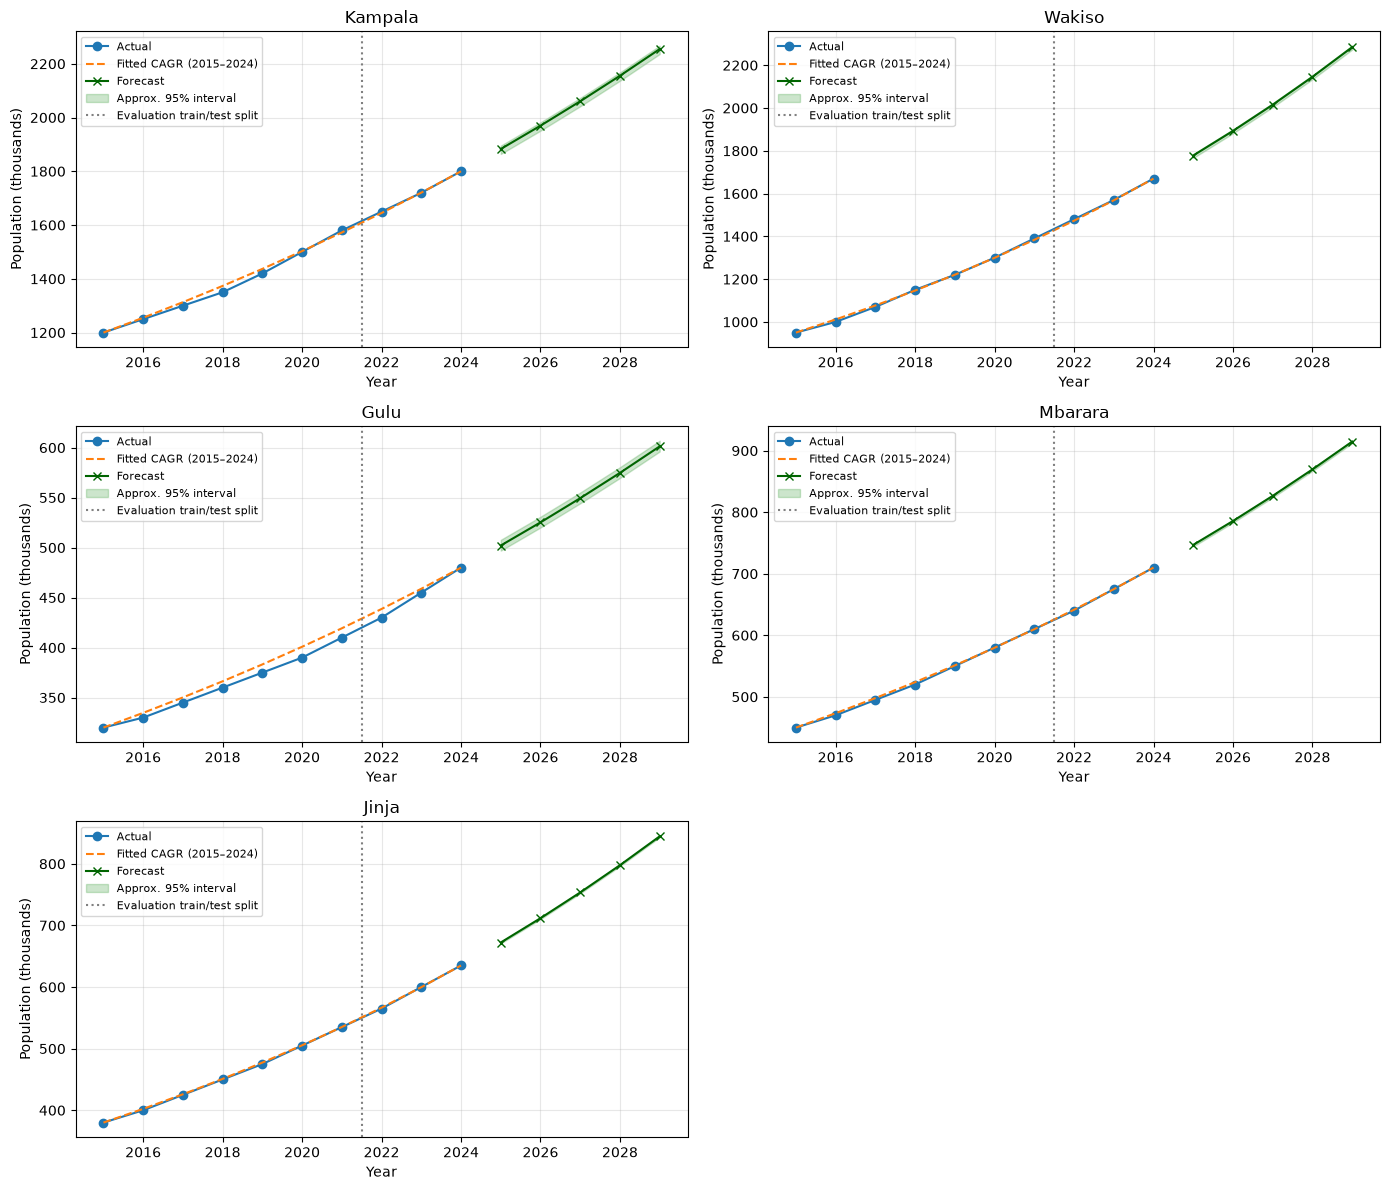

In [96]:
# Create five district charts in a shared figure.
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, district) in enumerate(districts.items()):
    ax = axes[i]
    lower, upper = prediction_intervals[name]

    # Plot the illustrative historical population values.
    ax.plot(
        district.years, district.populations,
        marker="o", label="Actual"
    )

    # Plot the historical CAGR curve fitted using all ten years.
    ax.plot(
        district.years, fitted_populations[name],
        linestyle="--", label="Fitted CAGR (2015–2024)"
    )

    # Show future forecasts and their approximate uncertainty intervals.
    ax.plot(
        forecast_years, forecasts[name],
        marker="x", color="darkgreen", label="Forecast"
    )
    ax.fill_between(
        forecast_years, lower, upper,
        color="green", alpha=0.2, label="Approx. 95% interval"
    )

    # Mark the boundary used in the earlier model evaluation.
    ax.axvline(
        2021.5, color="grey", linestyle=":",
        label="Evaluation train/test split"
    )

    # Label each chart with its district and measurement units.
    ax.set_title(name)
    ax.set_xlabel("Year")
    ax.set_ylabel("Population (thousands)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Remove the unused sixth panel and display the figure.
fig.delaxes(axes[5])
fig.tight_layout()
plt.show()

## 12. Findings & Limitations

CAGR produced the lowest test MAPE for all five districts, ranging from
approximately 0.10% for Mbarara to 2.02% for Gulu. It was therefore
selected and refitted using the full 2015–2024 dataset. These results
support CAGR for this illustrative dataset, but the three-year test
period provides limited evidence of future performance.

Wakiso had the fastest historical relative growth, with a CAGR of
6.47%. Assuming this growth continues, it also requires the largest
increase in classrooms by 2029: 2,088. Estimated additional requirements
are 1,544 for Kampala, 412 for Gulu, 695 for Mbarara and 712 for Jinja.
These figures assume that 2024 classroom needs are already met.

The Fibonacci model performed poorly because its imposed growth ratios
greatly exceed the observed district growth rates. A lower variance
among forecast population levels does not demonstrate greater accuracy,
particularly because historical and forecast periods differ in length.

The bootstrap extension provides approximate pointwise intervals from
1,000 residual resamples. However, only ten historical residuals are
available per district, and the method excludes growth-rate uncertainty
and time dependence.

All population data are illustrative. The forecasts omit migration,
policy changes and other demographic influences. Classroom estimates
also assume a constant 18% school-age share, full enrolment and
53 pupils per classroom. Verified population and school-capacity data
would be needed for actual planning.
